### 1) Normalización de nombres y tipos de columnas

- Se corrigen errores comunes en los nombres (p. ej. `0ppointment Type` → `Appointment Type`).
- Se eliminan espacios en columnas de texto y se convierten columnas numéricas a tipos numéricos.

In [1]:
# 02 - Limpieza de datos y primer modelo con Árbol de Decisión
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Rutas

repo_root = Path.cwd() 
RAW_PATH = repo_root / 'data' / 'raw' / 'database_non-shows.xlsx'
PROCESSED_DIR= repo_root / 'data' / 'processed'
if not os.path.exists(RAW_PATH):
    RAW_PATH = os.path.join('..', 'data', 'raw', 'database_non-shows.xlsx')

# Cargar
print('Cargando dataset desde:', RAW_PATH)
df = pd.read_excel(RAW_PATH)
print('Dataset cargado. Filas, columnas:', df.shape)

# Vista rápida
display(df.head())
print('\nColumnas:')
print(df.columns.tolist())

# Mostrar nulos y duplicados
print('\nValores nulos por columna:')
print(df.isnull().sum())
print('\nDuplicados totales:', df.duplicated().sum())

Cargando dataset desde: ..\data\raw\database_non-shows.xlsx
Dataset cargado. Filas, columnas: (18587, 13)


,Appointment Type,Age,Sex,Insurance Type,Number of Diseases,Recent Hospitalization,Number of Medications,Hour,Day,Month,Creation to Assignment Interval,Number of Previous Attendance,Number of Previous Non-Attendance
0,0,90,1,3,4,0,6,9,1,8,58,7,1
1,0,92,1,4,1,0,0,13,2,5,61,3,0
2,0,92,1,4,2,0,0,13,4,7,33,2,0
3,0,81,0,3,4,0,0,16,0,6,1,4,1
4,0,84,1,3,1,0,0,10,3,1,19,2,0



Columnas:
['Appointment Type', 'Age', 'Sex', 'Insurance Type', 'Number of Diseases', 'Recent Hospitalization', 'Number of Medications', 'Hour', 'Day', 'Month', 'Creation to Assignment Interval', 'Number of Previous Attendance', 'Number of Previous Non-Attendance']

Valores nulos por columna:
Appointment Type                     0
Age                                  0
Sex                                  0
Insurance Type                       0
Number of Diseases                   0
Recent Hospitalization               0
Number of Medications                0
Hour                                 0
Day                                  0
Month                                0
Creation to Assignment Interval      0
Number of Previous Attendance        0
Number of Previous Non-Attendance    0
dtype: int64

Duplicados totales: 6


In [2]:
# Normalizar nombres comunes y eliminar espacios en strings
# Map de correcciones conocidas (añadir si detectas otros errores)
rename_map = {
    'Appointment Type': 'Appointment Type',
    'Appointment_Type': 'Appointment Type',
    'AppointmentType': 'Appointment Type',
    'Number of diseases': 'Number of Diseases',
    'Number of diseases ': 'Number of Diseases',
}

# Aplicar renombrado sólo si existen las keys
existing_renames = {k:v for k,v in rename_map.items() if k in df.columns}
if existing_renames:
    df.rename(columns=existing_renames, inplace=True)
    print('Se aplicaron renombres:', existing_renames)

# Eliminar espacios en columnas string
for c in df.select_dtypes(include=['object']).columns:
    df[c] = df[c].astype(str).str.strip()

# Intentar convertir columnas numéricas conocidas a numeric
num_cols_candidates = ['Age', 'Number of Diseases', 'Recent Hospitalization', 'Number of Medications',
                       'Hour', 'Creation to Assignment Interval', 'Number of Previous Attendance', 'Number of Previous Non-Attendance']
for c in num_cols_candidates:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

print('\nTipos después de normalización:')
print(df.dtypes)

Se aplicaron renombres: {'Appointment Type': 'Appointment Type'}

Tipos después de normalización:
Appointment Type                     int64
Age                                  int64
Sex                                  int64
Insurance Type                       int64
Number of Diseases                   int64
Recent Hospitalization               int64
Number of Medications                int64
Hour                                 int64
Day                                  int64
Month                                int64
Creation to Assignment Interval      int64
Number of Previous Attendance        int64
Number of Previous Non-Attendance    int64
dtype: object


### 2) Eliminación de registros inválidos y duplicados

Se aplican reglas basadas en el diccionario del dataset para identificar registros con valores fuera de rango (ej.: Age <18 o >120, Hour fuera de 0-23, contadores negativos). Luego guardamos el resultado en `df_sin_errores_digitacion` y después removemos outliers extremos si procede.

In [3]:
# Reglas para identificar valores inválidos (según diccionario)
condiciones = {
    'Appointment Type': ~df['Appointment Type'].isin([0, 1]) if 'Appointment Type' in df.columns else pd.Series(False, index=df.index),
    'Age': (df['Age'] < 18) | (df['Age'] > 120) if 'Age' in df.columns else pd.Series(False, index=df.index),
    'Sex': ~df['Sex'].isin([0, 1, 2]) if 'Sex' in df.columns else pd.Series(False, index=df.index),
    'Insurance Type': ~df['Insurance Type'].isin(range(0, 9)) if 'Insurance Type' in df.columns else pd.Series(False, index=df.index),
    'Number of Diseases': (df['Number of Diseases'] < 0) if 'Number of Diseases' in df.columns else pd.Series(False, index=df.index),
    'Recent Hospitalization': (df['Recent Hospitalization'] < 0) if 'Recent Hospitalization' in df.columns else pd.Series(False, index=df.index),
    'Number of Medications': (df['Number of Medications'] < 0) if 'Number of Medications' in df.columns else pd.Series(False, index=df.index),
    'Hour': (df['Hour'] < 0) | (df['Hour'] > 23) if 'Hour' in df.columns else pd.Series(False, index=df.index),
    'Day': ~df['Day'].between(0, 6) if 'Day' in df.columns else pd.Series(False, index=df.index),
    'Month': ~df['Month'].between(1, 12) if 'Month' in df.columns else pd.Series(False, index=df.index),
    'Creation to Assignment Interval': (df['Creation to Assignment Interval'] < 0) if 'Creation to Assignment Interval' in df.columns else pd.Series(False, index=df.index),
    'Number of Previous Attendance': (df['Number of Previous Attendance'] < 0) if 'Number of Previous Attendance' in df.columns else pd.Series(False, index=df.index),
    'Number of Previous Non-Attendance': (df['Number of Previous Non-Attendance'] < 0) if 'Number of Previous Non-Attendance' in df.columns else pd.Series(False, index=df.index),
}

# Contar y combinar mascaras
count_invalid = 0
mask_invalid = pd.Series(False, index=df.index)
for col_name, cond in condiciones.items():
    if isinstance(cond, pd.Series):
        n = cond.sum()
        if n > 0:
            print(f"{n} valores inválidos en regla: {col_name}")
        count_invalid += int(n)
        mask_invalid = mask_invalid | cond

print('\nTotal de registros marcados como inválidos (con posible solapamiento):', count_invalid)

# Eliminar filas inválidas
df_sin_errores_digitacion = df[~mask_invalid].copy()
print('\nFilas antes:', len(df), 'Filas después de eliminar inválidos:', len(df_sin_errores_digitacion))

# Eliminar duplicados exactos
dup_count = df_sin_errores_digitacion.duplicated().sum()
if dup_count > 0:
    print('\nDuplicados encontrados:', dup_count)
    df_sin_errores_digitacion = df_sin_errores_digitacion.drop_duplicates()

print('\nFilas después de drop_duplicates:', len(df_sin_errores_digitacion))

51 valores inválidos en regla: Age
129 valores inválidos en regla: Day
36 valores inválidos en regla: Month
1 valores inválidos en regla: Creation to Assignment Interval

Total de registros marcados como inválidos (con posible solapamiento): 217

Filas antes: 18587 Filas después de eliminar inválidos: 18391

Duplicados encontrados: 6

Filas después de drop_duplicates: 18385


### 3) Tratamiento de outliers

- Eliminaremos registros con `Creation to Assignment Interval` > 365 (configurable).
- Opcionalmente se puede activar eliminación por IQR para variables continuas (disponible en código).

In [4]:
# Copiar df limpio base
df_limpio = df_sin_errores_digitacion.copy()

# Remover Creation to Assignment Interval excesivo
if 'Creation to Assignment Interval' in df_limpio.columns:
    n_before = len(df_limpio)
    df_limpio = df_limpio[df_limpio['Creation to Assignment Interval'] <= 365]
    print(f"Se eliminaron {n_before - len(df_limpio)} registros con Creation to Assignment Interval > 365")

# Función opcional para remover outliers por IQR en columnas numéricas
def remove_outliers_iqr(df, cols, k=1.5):
    df2 = df.copy()
    for c in cols:
        if c in df2.columns:
            Q1 = df2[c].quantile(0.25)
            Q3 = df2[c].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - k * IQR
            upper = Q3 + k * IQR
            df2 = df2[(df2[c].isna()) | ((df2[c] >= lower) & (df2[c] <= upper))]
    return df2

# Usar con precaución; por defecto está comentado
# num_cols_to_check = ['Age', 'Number of Diseases', 'Number of Medications', 'Creation to Assignment Interval']
# df_limpio = remove_outliers_iqr(df_limpio, num_cols_to_check, k=1.5)

print('\nFilas finales en df_limpio:', len(df_limpio))

# Guardar df_limpio
os.makedirs(PROCESSED_DIR, exist_ok=True)
processed_path = os.path.join(PROCESSED_DIR, 'df_limpio.csv')
df_limpio.to_csv(processed_path, index=False)
print('Dataset limpio guardado en:', processed_path)

Se eliminaron 1 registros con Creation to Assignment Interval > 365

Filas finales en df_limpio: 18384
Dataset limpio guardado en: c:\Users\alejo\Documents\SEMESTRE VIII\Proyecto de Grado\predictive-no-show-fvl\notebooks\data\processed\df_limpio.csv


---

## 4) Preparación para Modelado y primer Árbol de Decisión (sin balanceo)

- Convertiremos variables categóricas relevantes (Sex, Insurance Type, Day, Month) a dummies.
- Seleccionaremos features básicos y entrenaremos un `DecisionTreeClassifier` como baseline.
- No aplicamos balanceo de clases en esta primera iteración (tal como solicitaste).

In [5]:
# Preparación de features y entrenamiento de Decision Tree mejorado
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

# -------------------------------
# Selección de features
# -------------------------------
features_num = [c for c in ['Age', 'Number of Diseases', 'Recent Hospitalization', 'Number of Medications',
                             'Hour', 'Creation to Assignment Interval', 'Number of Previous Attendance',
                             'Number of Previous Non-Attendance'] if c in df_limpio.columns]

features_cat = [c for c in ['Sex', 'Insurance Type', 'Day', 'Month'] if c in df_limpio.columns]

print('Features numéricas:', features_num)
print('Features categóricas:', features_cat)

# -------------------------------
# Construir X, y
# -------------------------------
X = df_limpio[features_num + features_cat].copy()
y = df_limpio['Appointment Type']

# One-hot encode
if features_cat:
    X = pd.get_dummies(X, columns=features_cat, drop_first=True)

# Rellenar NA
X = X.fillna(X.median())

# Escalar numéricas (opcional pero mejora el modelo)
scaler = StandardScaler()
X[features_num] = scaler.fit_transform(X[features_num])

# -------------------------------
# Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=None
)

# -------------------------------
# Modelo base mejorado
# -------------------------------
clf = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    criterion='entropy'
)

clf.fit(X_train, y_train)

# -------------------------------
# Predicción y evaluación
# -------------------------------
y_pred = clf.predict(X_test)

print('\nAccuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, digits=3))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred))

# -------------------------------
# Importancia de features
# -------------------------------
if hasattr(clf, 'feature_importances_'):
    fi = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
    print('\nTop 10 features por importancia:')
    display(fi.head(10))

# -------------------------------
# GridSearchCV para encontrar mejor árbol sin balancear
# -------------------------------
param_grid = {
    'max_depth': [6, 8, 10, 12, None],
    'min_samples_split': [10, 20, 50, 100],
    'min_samples_leaf': [5, 10, 20, 40],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\nMejores parámetros encontrados:")
print(grid.best_params_)

best_clf = grid.best_estimator_
y_pred_best = best_clf.predict(X_test)

print('\nAccuracy (GridSearch):', accuracy_score(y_test, y_pred_best))
print('\nClassification Report (GridSearch):\n')
print(classification_report(y_test, y_pred_best, digits=3))
print('\nConfusion Matrix (GridSearch):')
print(confusion_matrix(y_test, y_pred_best))


# ================================================================
# 🔥 ENTRENAMIENTO REPETIDO (10 seeds) → Escoger el mejor modelo
# ================================================================

print("\n================ ENTRENAMIENTO REPETIDO ==================\n")

results = []
N_REPETICIONES = 10

for seed in range(N_REPETICIONES):
    clf_rep = DecisionTreeClassifier(
        random_state=seed,
        max_depth=best_clf.max_depth,
        min_samples_split=best_clf.min_samples_split,
        min_samples_leaf=best_clf.min_samples_leaf,
        criterion=best_clf.criterion
    )
    
    clf_rep.fit(X_train, y_train)
    y_pred_rep = clf_rep.predict(X_test)

    acc = accuracy_score(y_test, y_pred_rep)
    results.append((seed, acc, clf_rep))

    print(f"🏁 Iteración {seed+1}/{N_REPETICIONES} → Accuracy: {acc:.4f}")

# Elegir el mejor modelo repetido
best_seed, best_acc, best_model_rep = max(results, key=lambda x: x[1])

print("\n🎉 Mejor modelo encontrado tras repetir 10 veces:")
print("Seed:", best_seed)
print("Accuracy:", best_acc)

# Reporte final del mejor modelo repetido
y_pred_final = best_model_rep.predict(X_test)

print("\nClassification Report (MEJOR MODELO REPETIDO):\n")
print(classification_report(y_test, y_pred_final, digits=3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))


Features numéricas: ['Age', 'Number of Diseases', 'Recent Hospitalization', 'Number of Medications', 'Hour', 'Creation to Assignment Interval', 'Number of Previous Attendance', 'Number of Previous Non-Attendance']
Features categóricas: ['Sex', 'Insurance Type', 'Day', 'Month']

Accuracy: 0.7772640739733478

Classification Report:

              precision    recall  f1-score   support

           0      0.834     0.836     0.835      2477
           1      0.660     0.656     0.658      1200

    accuracy                          0.777      3677
   macro avg      0.747     0.746     0.746      3677
weighted avg      0.777     0.777     0.777      3677


Confusion Matrix:
[[2071  406]
 [ 413  787]]

Top 10 features por importancia:


Number of Previous Non-Attendance    0.299900
Hour                                 0.108156
Month_11                             0.098607
Month_12                             0.097558
Month_10                             0.095595
Number of Previous Attendance        0.072468
Day_6                                0.057211
Day_5                                0.044226
Number of Medications                0.034824
Number of Diseases                   0.028960
dtype: float64

C:\Users\alejo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



Mejores parámetros encontrados:
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 20, 'min_samples_split': 100}

Accuracy (GridSearch): 0.7846070165896111

Classification Report (GridSearch):

              precision    recall  f1-score   support

           0      0.812     0.885     0.847      2477
           1      0.708     0.578     0.637      1200

    accuracy                          0.785      3677
   macro avg      0.760     0.731     0.742      3677
weighted avg      0.778     0.785     0.778      3677


Confusion Matrix (GridSearch):
[[2191  286]
 [ 506  694]]

================ ENTRENAMIENTO REPETIDO ==================

🏁 Iteración 1/10 → Accuracy: 0.7846
🏁 Iteración 2/10 → Accuracy: 0.7871
🏁 Iteración 3/10 → Accuracy: 0.7871
🏁 Iteración 4/10 → Accuracy: 0.7871
🏁 Iteración 5/10 → Accuracy: 0.7846
🏁 Iteración 6/10 → Accuracy: 0.7846
🏁 Iteración 7/10 → Accuracy: 0.7871
🏁 Iteración 8/10 → Accuracy: 0.7846
🏁 Iteración 9/10 → Accuracy: 0.7871
🏁 Iteración 10/10 → Accu

In [8]:
# ============================================================
# MODELOS: RANDOM FOREST + XGBOOST (SIN BALANCEAR)
# ============================================================

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# ============================================================
# PREPARACIÓN DE FEATURES
# ============================================================

features_num = [c for c in ['Age', 'Number of Diseases', 'Recent Hospitalization', 'Number of Medications',
                             'Hour', 'Creation to Assignment Interval', 'Number of Previous Attendance',
                             'Number of Previous Non-Attendance'] if c in df_limpio.columns]

features_cat = [c for c in ['Sex', 'Insurance Type', 'Day', 'Month'] if c in df_limpio.columns]

print("Features numéricas:", features_num)
print("Features categóricas:", features_cat)

# Construir X, y
X = df_limpio[features_num + features_cat].copy()
y = df_limpio["Appointment Type"]

# One-hot encoding
if features_cat:
    X = pd.get_dummies(X, columns=features_cat, drop_first=True)

# Rellenar NA
X = X.fillna(X.median())

# Escalar numéricas
scaler = StandardScaler()
X[features_num] = scaler.fit_transform(X[features_num])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================================
# 1. RANDOM FOREST (SIN BALANCEO)
# ============================================================

print("\n===============================================")
print(" ENTRENANDO RANDOM FOREST (SIN BALANCEO)")
print("===============================================\n")

rf_param_grid = {
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [None, 10, 30, 50],
    "min_samples_split": [2, 10, 50],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True],
    "criterion": ["gini", "entropy"]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)


rf_grid.fit(X_train, y_train)

print("Mejores parámetros RF:", rf_grid.best_params_)

rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)

print("\nAccuracy (Random Forest):", accuracy_score(y_test, rf_pred))
print("\nClassification Report (Random Forest):\n")
print(classification_report(y_test, rf_pred, digits=3))

print("\nConfusion Matrix (Random Forest):")
print(confusion_matrix(y_test, rf_pred))

# Importancia de features
fi_rf = pd.Series(rf_best.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 10 features RF:")
display(fi_rf.head(10))


Features numéricas: ['Age', 'Number of Diseases', 'Recent Hospitalization', 'Number of Medications', 'Hour', 'Creation to Assignment Interval', 'Number of Previous Attendance', 'Number of Previous Non-Attendance']
Features categóricas: ['Sex', 'Insurance Type', 'Day', 'Month']

 ENTRENANDO RANDOM FOREST (SIN BALANCEO)

Mejores parámetros RF: {'bootstrap': True, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 600}
Mejores parámetros RF: {'bootstrap': True, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 600}
Mejores parámetros RF: {'bootstrap': True, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 600}

Accuracy (Random Forest): 0.8058199619254828

Classification Report (Random Forest):

              precision    recall  f1-score   support

         

Number of Previous Non-Attendance    0.173157
Creation to Assignment Interval      0.088941
Hour                                 0.087090
Number of Previous Attendance        0.085928
Age                                  0.085827
Number of Diseases                   0.055017
Month_11                             0.054054
Month_12                             0.051418
Month_10                             0.048809
Day_6                                0.032380
dtype: float64

In [9]:
# ============================================================
# 2. XGBOOST (SIN BALANCEO)
# ============================================================

print("\n===============================================")
print(" ENTRENANDO XGBOOST (SIN BALANCEO)")
print("===============================================\n")

xgb_param_grid = {
    "n_estimators": [300, 500, 700],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0],
    "gamma": [0, 0.1, 0.3],
    "min_child_weight": [1, 5, 10],
    "reg_lambda": [1, 2, 5],
    "reg_alpha": [0, 0.1, 0.5]
}

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_grid = GridSearchCV(
    xgb,
    xgb_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Mejores parámetros XGB:", xgb_grid.best_params_)

xgb_best = xgb_grid.best_estimator_
xgb_pred = xgb_best.predict(X_test)

print("\nAccuracy (XGBoost):", accuracy_score(y_test, xgb_pred))
print("\nClassification Report (XGBoost):\n")
print(classification_report(y_test, xgb_pred, digits=3))

print("\nConfusion Matrix (XGBoost):")
print(confusion_matrix(y_test, xgb_pred))

# Importancia de features XGB
fi_xgb = pd.Series(xgb_best.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 10 features XGB:")
display(fi_xgb.head(10))



 ENTRENANDO XGBOOST (SIN BALANCEO)

Mejores parámetros XGB: {'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 500, 'reg_alpha': 0.1, 'reg_lambda': 2, 'subsample': 1.0}

Accuracy (XGBoost): 0.8118031003535491

Classification Report (XGBoost):

              precision    recall  f1-score   support

           0      0.835     0.899     0.865      2477
           1      0.751     0.632     0.687      1200

    accuracy                          0.812      3677
   macro avg      0.793     0.766     0.776      3677
weighted avg      0.808     0.812     0.807      3677


Confusion Matrix (XGBoost):
[[2226  251]
 [ 441  759]]

Top 10 features XGB:
Mejores parámetros XGB: {'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 500, 'reg_alpha': 0.1, 'reg_lambda': 2, 'subsample': 1.0}

Accuracy (XGBoost): 0.8118031003535491

Classification Report (XGBoost):

        

Month_10                             0.154289
Month_11                             0.144108
Month_12                             0.144094
Day_5                                0.060673
Day_6                                0.059157
Number of Previous Non-Attendance    0.055007
Insurance Type_1                     0.024414
Hour                                 0.022678
Sex_2                                0.021962
Day_2                                0.020826
dtype: float32

---

## 5) Balanceo de Clases con SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) genera ejemplos sintéticos de la clase minoritaria para balancear el dataset. Esto ayuda a mejorar las métricas en clases desbalanceadas.

Entrenaremos modelos con:
- **XGBoost** (mejor modelo sin balanceo)
- **Random Forest**
- **Decision Tree**

Objetivo: **Accuracy > 80%, F1-Score > 80%, Cohen's Kappa alto**

In [7]:
# ============================================================
# BALANCEO DE CLASES CON SMOTE
# ============================================================

from imblearn.over_sampling import SMOTE
from sklearn.metrics import cohen_kappa_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import pandas as pd
import numpy as np
import os

# ============================================================
# VERIFICAR Y CARGAR/RECONSTRUIR VARIABLES NECESARIAS
# ============================================================

print("🔍 Verificando variables necesarias...\n")

# Paso 1: Verificar df_limpio
if 'df_limpio' not in globals():
    print("⚠️  df_limpio no encontrado.")
    
    # Intentar cargar desde archivo
    try:
        # Buscar en múltiples ubicaciones posibles
        possible_paths = [
            Path.cwd() / 'data' / 'processed' / 'df_limpio.csv',
            Path('..') / 'data' / 'processed' / 'df_limpio.csv',
            Path('data') / 'processed' / 'df_limpio.csv',
            Path.cwd().parent / 'data' / 'processed' / 'df_limpio.csv'
        ]
        
        processed_path = None
        for path in possible_paths:
            if path.exists():
                processed_path = path
                break
        
        if processed_path:
            print(f"📂 Cargando df_limpio desde: {processed_path.absolute()}")
            df_limpio = pd.read_csv(processed_path)
            print(f"✅ df_limpio cargado. Shape: {df_limpio.shape}")
        else:
            print("\n❌ ERROR: No se pudo encontrar df_limpio.csv")
            print("\n🔍 Se buscó en:")
            for p in possible_paths:
                print(f"   - {p.absolute()}")
            print("\n📋 SOLUCIÓN: Ejecuta estas celdas en orden:")
            print("   1. Celda 2: Cargar datos")
            print("   2. Celda 3: Normalización")
            print("   3. Celda 5: Limpieza de inválidos")
            print("   4. Celda 7: Tratamiento de outliers (guarda df_limpio.csv)")
            print("   5. Luego vuelve a ejecutar esta celda")
            raise FileNotFoundError("df_limpio.csv no encontrado en ninguna ubicación esperada.")
    except NameError:
        print(f"\n❌ Error: pandas no está importado. Reintentando...")
        import pandas as pd
        # Reintentar la carga
        for path in possible_paths:
            if path.exists():
                print(f"📂 Cargando df_limpio desde: {path.absolute()}")
                df_limpio = pd.read_csv(path)
                print(f"✅ df_limpio cargado. Shape: {df_limpio.shape}")
                break
    except Exception as e:
        print(f"\n❌ Error al cargar df_limpio: {str(e)}")
        raise
else:
    print("✅ df_limpio encontrado.")

# Paso 2: Verificar o reconstruir X_train y y_train
if 'X_train' not in globals() or 'y_train' not in globals():
    print("⚠️  X_train/y_train no encontrados. Reconstruyendo desde df_limpio...\n")
    
    # Reconstruir features
    features_num = [c for c in ['Age', 'Number of Diseases', 'Recent Hospitalization', 'Number of Medications',
                                 'Hour', 'Creation to Assignment Interval', 'Number of Previous Attendance',
                                 'Number of Previous Non-Attendance'] if c in df_limpio.columns]
    
    features_cat = [c for c in ['Sex', 'Insurance Type', 'Day', 'Month'] if c in df_limpio.columns]
    
    print(f"✓ Features numéricas: {len(features_num)}")
    print(f"✓ Features categóricas: {len(features_cat)}")
    
    # Construir X, y
    X = df_limpio[features_num + features_cat].copy()
    y = df_limpio['Appointment Type']
    
    # One-hot encode
    if features_cat:
        X = pd.get_dummies(X, columns=features_cat, drop_first=True)
    
    # Rellenar NA
    X = X.fillna(X.median())
    
    # Escalar numéricas
    scaler = StandardScaler()
    X[features_num] = scaler.fit_transform(X[features_num])
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=None
    )
    
    print(f"\n✅ Variables reconstruidas exitosamente!")
    print(f"   X_train shape: {X_train.shape}")
    print(f"   X_test shape: {X_test.shape}")
    print(f"   y_train shape: {y_train.shape}")
    print(f"   y_test shape: {y_test.shape}")
else:
    print("✅ Variables X_train/y_train encontradas.")

# ============================================================
# APLICAR SMOTE
# ============================================================

# Verificar balanceo original
print("\n" + "="*50)
print("📊 DISTRIBUCIÓN ORIGINAL DE CLASES")
print("="*50)
print("\nConteo de clases:")
print(y_train.value_counts().sort_index())
print(f"\nPorcentaje clase 0 (Asistencia): {(y_train.value_counts()[0]/len(y_train)*100):.2f}%")
print(f"Porcentaje clase 1 (No-Show):    {(y_train.value_counts()[1]/len(y_train)*100):.2f}%")

# Aplicar SMOTE
print("\n🔄 Aplicando SMOTE...")
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n" + "="*50)
print("📊 DISTRIBUCIÓN DESPUÉS DE SMOTE")
print("="*50)
print("\nConteo de clases:")
print(pd.Series(y_train_smote).value_counts().sort_index())
print(f"\nPorcentaje clase 0 (Asistencia): {(pd.Series(y_train_smote).value_counts()[0]/len(y_train_smote)*100):.2f}%")
print(f"Porcentaje clase 1 (No-Show):    {(pd.Series(y_train_smote).value_counts()[1]/len(y_train_smote)*100):.2f}%")
print("="*50)

print(f"\n✅ SMOTE aplicado exitosamente!")
print(f"   Registros originales: {len(X_train)}")
print(f"   Registros balanceados: {len(X_train_smote)}")
print(f"   Nuevos ejemplos sintéticos: {len(X_train_smote) - len(X_train)}")
print("\n🎉 ¡Listo para entrenar modelos con datos balanceados!")

🔍 Verificando variables necesarias...

⚠️  df_limpio no encontrado.
📂 Cargando df_limpio desde: c:\Users\alejo\Documents\SEMESTRE VIII\Proyecto de Grado\predictive-no-show-fvl\notebooks\data\processed\df_limpio.csv
✅ df_limpio cargado. Shape: (18384, 13)
⚠️  X_train/y_train no encontrados. Reconstruyendo desde df_limpio...

✓ Features numéricas: 8
✓ Features categóricas: 4

✅ Variables reconstruidas exitosamente!
   X_train shape: (14707, 35)
   X_test shape: (3677, 35)
   y_train shape: (14707,)
   y_test shape: (3677,)

📊 DISTRIBUCIÓN ORIGINAL DE CLASES

Conteo de clases:
Appointment Type
0    9634
1    5073
Name: count, dtype: int64

Porcentaje clase 0 (Asistencia): 65.51%
Porcentaje clase 1 (No-Show):    34.49%

🔄 Aplicando SMOTE...


C:\Users\alejo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\alejo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^


📊 DISTRIBUCIÓN DESPUÉS DE SMOTE

Conteo de clases:
Appointment Type
0    9634
1    9634
Name: count, dtype: int64

Porcentaje clase 0 (Asistencia): 50.00%
Porcentaje clase 1 (No-Show):    50.00%

✅ SMOTE aplicado exitosamente!
   Registros originales: 14707
   Registros balanceados: 19268
   Nuevos ejemplos sintéticos: 4561

🎉 ¡Listo para entrenar modelos con datos balanceados!


### 5.1) XGBoost con SMOTE - Grid Search Exhaustivo

Entrenaremos XGBoost con datos balanceados y búsqueda exhaustiva de hiperparámetros.

In [14]:
# ============================================================
# XGBOOST CON SMOTE - GRID SEARCH OPTIMIZADO
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

print("\n" + "="*70)
print(" ENTRENANDO XGBOOST CON SMOTE (Optimizado Rápido)")
print("="*70 + "\n")

xgb_param_dist = {
    'n_estimators': [300, 500, 700],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_smote = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    tree_method='hist'  
)

xgb_random = RandomizedSearchCV(
    xgb_smote,
    xgb_param_dist,
    n_iter=20,  # SOLO 20 combinaciones
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Iniciando búsqueda optimizada...")
xgb_random.fit(X_train_smote, y_train_smote)

print("\n✅ Búsqueda completada!")
print("\nMejores parámetros encontrados:")
for param, value in xgb_random.best_params_.items():
    print(f"  {param}: {value}")

xgb_best_smote = xgb_random.best_estimator_


 ENTRENANDO XGBOOST CON SMOTE (Optimizado Rápido)

Iniciando búsqueda optimizada...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Búsqueda completada!

Mejores parámetros encontrados:
  subsample: 0.8
  n_estimators: 500
  max_depth: 7
  learning_rate: 0.05
  colsample_bytree: 1.0


In [15]:
# ============================
# PREDICCIONES Y MÉTRICAS
# ============================

from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, classification_report, confusion_matrix

# Predicciones
y_pred_xgb_smote = xgb_best_smote.predict(X_test)

# Métricas
acc_xgb_smote = accuracy_score(y_test, y_pred_xgb_smote)
f1_xgb_smote = f1_score(y_test, y_pred_xgb_smote, average='macro')
kappa_xgb_smote = cohen_kappa_score(y_test, y_pred_xgb_smote)

print("\n" + "="*70)
print(" RESULTADOS XGBOOST CON SMOTE")
print("="*70)
print(f"\n🎯 Accuracy:      {acc_xgb_smote:.4f} ({acc_xgb_smote*100:.2f}%)")
print(f"🎯 F1-Score:      {f1_xgb_smote:.4f} ({f1_xgb_smote*100:.2f}%)")
print(f"🎯 Cohen's Kappa: {kappa_xgb_smote:.4f}")

print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred_xgb_smote, digits=4))

print("📊 Confusion Matrix:")
cm_xgb_smote = confusion_matrix(y_test, y_pred_xgb_smote)
print(cm_xgb_smote)


 RESULTADOS XGBOOST CON SMOTE

🎯 Accuracy:      0.8162 (81.62%)
🎯 F1-Score:      0.7843 (78.43%)
🎯 Cohen's Kappa: 0.5693

📊 Classification Report:

              precision    recall  f1-score   support

           0     0.8446    0.8910    0.8672      2477
           1     0.7462    0.6617    0.7014      1200

    accuracy                         0.8162      3677
   macro avg     0.7954    0.7763    0.7843      3677
weighted avg     0.8125    0.8162    0.8131      3677

📊 Confusion Matrix:
[[2207  270]
 [ 406  794]]


### 5.2) Random Forest con SMOTE - Grid Search Exhaustivo


 RANDOM FOREST CON SMOTE - MODELO FINAL

🔥 Mejor threshold encontrado: 0.4755

 RESULTADOS RANDOM FOREST OPTIMIZADO

🎯 Accuracy:            0.7960
🎯 Balanced Accuracy:   0.7900
🎯 F1 Macro:            0.7770
🎯 F1 Weighted:         0.7996
🎯 Precision (Clase 1): 0.6603
🎯 Recall (Clase 1):    0.7725
🎯 ROC-AUC:             0.8783
🎯 PR-AUC:              0.7907
🎯 Cohen's Kappa:       0.5556

📊 Classification Report:

              precision    recall  f1-score   support

           0     0.8799    0.8074    0.8421      2477
           1     0.6603    0.7725    0.7120      1200

    accuracy                         0.7960      3677
   macro avg     0.7701    0.7900    0.7770      3677
weighted avg     0.8082    0.7960    0.7996      3677



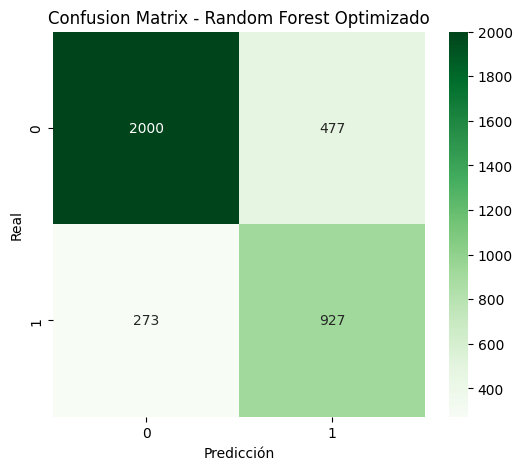

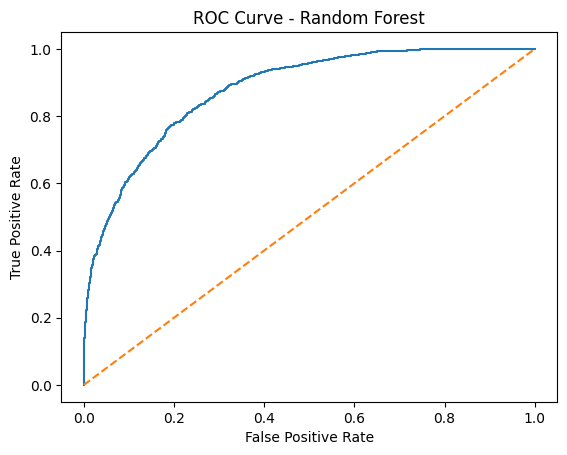

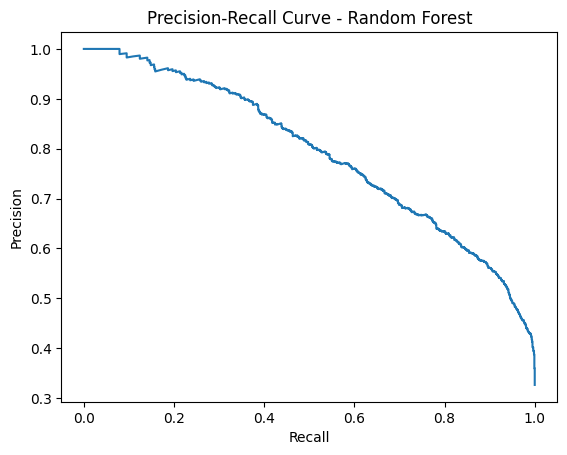


📈 Top 10 Features más importantes:
Number of Previous Non-Attendance    0.249754
Number of Previous Attendance        0.082165
Hour                                 0.081458
Creation to Assignment Interval      0.069269
Number of Diseases                   0.066705
Age                                  0.060743
Number of Medications                0.053706
Month_11                             0.048334
Month_12                             0.045232
Month_10                             0.040939
dtype: float64


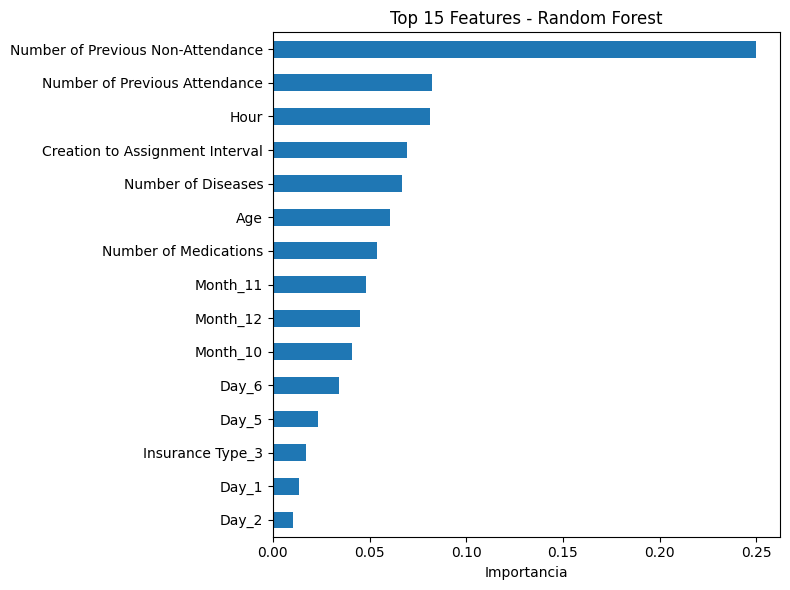

In [20]:
# ============================================================
# RANDOM FOREST CON SMOTE - MODELO FINAL OPTIMIZADO
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    classification_report, confusion_matrix,
    roc_auc_score, precision_score, recall_score,
    balanced_accuracy_score, precision_recall_curve,
    auc, roc_curve
)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

print("\n" + "="*70)
print(" RANDOM FOREST CON SMOTE - MODELO FINAL")
print("="*70 + "\n")

# ============================================================
# 1️⃣ MODELO CON MEJORES PARÁMETROS AJUSTADOS
# ============================================================

rf_best = RandomForestClassifier(
    n_estimators=600,          # Más estabilidad
    max_depth=20,              # Control de sobreajuste
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    class_weight='balanced',   # Mantener por desbalance
    random_state=42,
    n_jobs=-1
)

rf_best.fit(X_train_smote, y_train_smote)

# ============================================================
# 2️⃣ PROBABILIDADES
# ============================================================

y_proba = rf_best.predict_proba(X_test)[:, 1]

# ============================================================
# 3️⃣ OPTIMIZACIÓN AUTOMÁTICA DE THRESHOLD
# ============================================================

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)

best_threshold = thresholds[np.argmax(f1_scores)]
print(f"🔥 Mejor threshold encontrado: {best_threshold:.4f}")

y_pred_opt = (y_proba >= best_threshold).astype(int)

# ============================================================
# 4️⃣ MÉTRICAS COMPLETAS
# ============================================================

acc = accuracy_score(y_test, y_pred_opt)
balanced_acc = balanced_accuracy_score(y_test, y_pred_opt)
f1_macro = f1_score(y_test, y_pred_opt, average='macro')
f1_weighted = f1_score(y_test, y_pred_opt, average='weighted')
precision_cls1 = precision_score(y_test, y_pred_opt)
recall_cls1 = recall_score(y_test, y_pred_opt)
roc_auc = roc_auc_score(y_test, y_proba)
kappa = cohen_kappa_score(y_test, y_pred_opt)

pr_auc = auc(recall, precision)

print("\n" + "="*70)
print(" RESULTADOS RANDOM FOREST OPTIMIZADO")
print("="*70)

print(f"\n🎯 Accuracy:            {acc:.4f}")
print(f"🎯 Balanced Accuracy:   {balanced_acc:.4f}")
print(f"🎯 F1 Macro:            {f1_macro:.4f}")
print(f"🎯 F1 Weighted:         {f1_weighted:.4f}")
print(f"🎯 Precision (Clase 1): {precision_cls1:.4f}")
print(f"🎯 Recall (Clase 1):    {recall_cls1:.4f}")
print(f"🎯 ROC-AUC:             {roc_auc:.4f}")
print(f"🎯 PR-AUC:              {pr_auc:.4f}")
print(f"🎯 Cohen's Kappa:       {kappa:.4f}")

print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred_opt, digits=4))

# ============================================================
# 5️⃣ MATRIZ DE CONFUSIÓN
# ============================================================

cm = confusion_matrix(y_test, y_pred_opt)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest Optimizado")
plt.ylabel("Real")
plt.xlabel("Predicción")
plt.show()

# ============================================================
# 6️⃣ CURVA ROC
# ============================================================

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# ============================================================
# 7️⃣ CURVA PRECISION-RECALL
# ============================================================

plt.figure()
plt.plot(recall, precision)
plt.title("Precision-Recall Curve - Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# ============================================================
# 8️⃣ FEATURE IMPORTANCE
# ============================================================

fi = pd.Series(
    rf_best.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\n📈 Top 10 Features más importantes:")
print(fi.head(10))

plt.figure(figsize=(8,6))
fi.head(15).plot(kind='barh')
plt.title("Top 15 Features - Random Forest")
plt.xlabel("Importancia")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 5.3) Decision Tree con SMOTE - Grid Search


 DECISION TREE CON SMOTE - OPTIMIZACIÓN AVANZADA

Fitting 5 folds for each of 25 candidates, totalling 125 fits

✅ Mejores parámetros:
{'min_samples_split': 30, 'min_samples_leaf': 2, 'max_depth': 20, 'criterion': 'entropy', 'ccp_alpha': 0.0}

🔥 Mejor threshold encontrado: 0.4934

 RESULTADOS OPTIMIZADOS DECISION TREE

🎯 Accuracy:            0.7604
🎯 Balanced Accuracy:   0.7515
🎯 F1 Macro:            0.7390
🎯 F1 Weighted:         0.7649
🎯 Precision (Clase 1): 0.6121
🎯 Recall (Clase 1):    0.7258
🎯 ROC-AUC:             0.8253
🎯 PR-AUC:              0.7291
🎯 Cohen's Kappa:       0.4800

📊 Classification Report:

              precision    recall  f1-score   support

           0     0.8540    0.7771    0.8138      2477
           1     0.6121    0.7258    0.6641      1200

    accuracy                         0.7604      3677
   macro avg     0.7331    0.7515    0.7390      3677
weighted avg     0.7751    0.7604    0.7649      3677



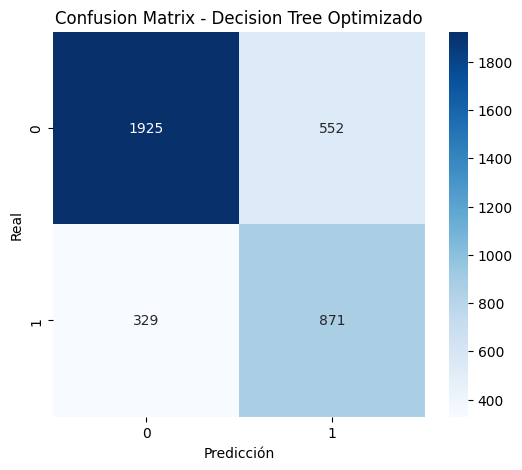

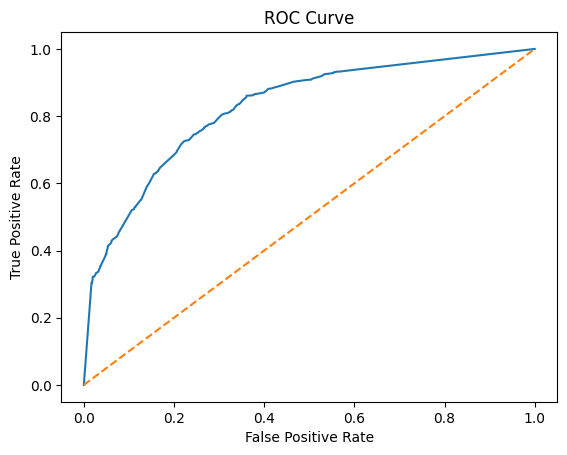

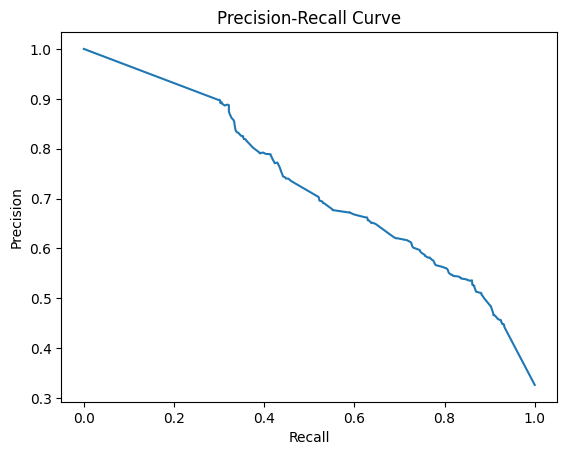


📈 Top 10 Features:
Number of Previous Non-Attendance    0.317278
Hour                                 0.098545
Number of Previous Attendance        0.085850
Creation to Assignment Interval      0.061057
Month_11                             0.058992
Month_12                             0.056886
Month_10                             0.054325
Number of Medications                0.053068
Number of Diseases                   0.040188
Age                                  0.034958
dtype: float64


In [18]:
# ============================================================
# DECISION TREE CON SMOTE - OPTIMIZACIÓN PROFESIONAL
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    classification_report, confusion_matrix,
    roc_auc_score, precision_score, recall_score,
    balanced_accuracy_score, precision_recall_curve, auc, roc_curve
)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

print("\n" + "="*70)
print(" DECISION TREE CON SMOTE - OPTIMIZACIÓN AVANZADA")
print("="*70 + "\n")

# ============================================================
# 1️⃣ BÚSQUEDA DE HIPERPARÁMETROS (Incluye poda)
# ============================================================

dt_param_dist = {
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'ccp_alpha': [0.0, 0.0005, 0.001, 0.005]  # 🔥 poda
}

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_random = RandomizedSearchCV(
    dt_model,
    dt_param_dist,
    n_iter=25,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

dt_random.fit(X_train_smote, y_train_smote)

print("\n✅ Mejores parámetros:")
print(dt_random.best_params_)

dt_best = dt_random.best_estimator_

# ============================================================
# 2️⃣ PREDICCIONES
# ============================================================

y_proba = dt_best.predict_proba(X_test)[:, 1]

# ============================================================
# 3️⃣ OPTIMIZAR THRESHOLD AUTOMÁTICAMENTE
# ============================================================

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)

best_threshold = thresholds[np.argmax(f1_scores)]
print(f"\n🔥 Mejor threshold encontrado: {best_threshold:.4f}")

y_pred_opt = (y_proba >= best_threshold).astype(int)

# ============================================================
# 4️⃣ MÉTRICAS COMPLETAS
# ============================================================

acc = accuracy_score(y_test, y_pred_opt)
f1_macro = f1_score(y_test, y_pred_opt, average='macro')
f1_weighted = f1_score(y_test, y_pred_opt, average='weighted')
precision_cls1 = precision_score(y_test, y_pred_opt)
recall_cls1 = recall_score(y_test, y_pred_opt)
roc_auc = roc_auc_score(y_test, y_proba)
kappa = cohen_kappa_score(y_test, y_pred_opt)
balanced_acc = balanced_accuracy_score(y_test, y_pred_opt)

pr_auc = auc(recall, precision)

print("\n" + "="*70)
print(" RESULTADOS OPTIMIZADOS DECISION TREE")
print("="*70)

print(f"\n🎯 Accuracy:            {acc:.4f}")
print(f"🎯 Balanced Accuracy:   {balanced_acc:.4f}")
print(f"🎯 F1 Macro:            {f1_macro:.4f}")
print(f"🎯 F1 Weighted:         {f1_weighted:.4f}")
print(f"🎯 Precision (Clase 1): {precision_cls1:.4f}")
print(f"🎯 Recall (Clase 1):    {recall_cls1:.4f}")
print(f"🎯 ROC-AUC:             {roc_auc:.4f}")
print(f"🎯 PR-AUC:              {pr_auc:.4f}")
print(f"🎯 Cohen's Kappa:       {kappa:.4f}")

print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred_opt, digits=4))

# ============================================================
# 5️⃣ MATRIZ DE CONFUSIÓN
# ============================================================

cm = confusion_matrix(y_test, y_pred_opt)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree Optimizado")
plt.ylabel("Real")
plt.xlabel("Predicción")
plt.show()

# ============================================================
# 6️⃣ CURVA ROC
# ============================================================

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# ============================================================
# 7️⃣ CURVA PRECISION-RECALL
# ============================================================

plt.figure()
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# ============================================================
# 8️⃣ FEATURE IMPORTANCE
# ============================================================

fi = pd.Series(
    dt_best.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\n📈 Top 10 Features:")
print(fi.head(10))